# ระบบจัดเมนูอาหาร 3 มื้อต่อวันด้วย Neural Network

## แนวคิด
เปลี่ยนจากงานเดิมที่ทำนาย `Low / Medium / High` เป็นระบบที่ใช้ **Neural Network (MLP)** เพื่อเรียนรู้ว่าอาหารแต่ละรายการมีความเหมาะสมต่อการนำไปจัดเมนูหรือไม่ แล้วนำผลการทำนายไปใช้จัด **อาหารเช้า กลางวัน และเย็น** โดยควบคุมพลังงานรวมไม่ให้เกินเป้าหมายต่อวัน

### Pipeline
1. อ่านและเตรียมข้อมูลโภชนาการ
2. สร้าง Target `meal_suitability` จากพลังงานของอาหารเมื่อเทียบกับช่วงพลังงานที่เหมาะสม
3. แยกข้อมูล Train / Validation / Test
4. Standardization
5. Train Neural Network ด้วย `MLPClassifier`
6. เปรียบเทียบโครงสร้าง Hidden Layer
7. ทดลองจำนวน Epoch
8. ใช้ NN ทำนายอาหารที่เหมาะสม
9. จัดอาหารเป็น 3 มื้อ และตรวจสอบ kcal รวม

> หมายเหตุ: Dataset เดิมไม่มีข้อมูลสูตรอาหาร ปริมาณต่อหนึ่งเสิร์ฟ และประเภทมื้อจริง ดังนั้นระบบนี้เป็น **ต้นแบบสำหรับการเรียน Machine Learning / Neural Network**

## สำคัญ: ชื่อคอลัมน์ Energy ของ Dataset นี้

Dataset เดิมไม่ได้ใช้ชื่อคอลัมน์ว่า `Energy` แต่ใช้ชื่อ:

`Energy, by calculation (kcal)`

ดังนั้น Notebook ฉบับแก้ไขนี้กำหนดตัวแปร `energy_col` เพื่ออ้างอิงชื่อคอลัมน์จริง และจะไม่เกิด `KeyError: 'Energy'` อีก

In [175]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("group_t_nutrition_complete.csv")

# ชื่อคอลัมน์ Energy จริงของ Dataset เดิม
energy_col = "Energy, by calculation (kcal)"

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (314, 39)


,number,food_code,thai_name,english_name,scientific_name,Ash (g),Calcium (mg),"Carbohydrate, available (g)","Carbohydrate, total (g)",Cholesterol (mg),...,Riboflavin (mg),Sodium (mg),"Sugars, total (g)",Thiamin (mg),Total energy - by calculation (kcal),Vitamin A; retinol activity equivalent (mcg),Vitamin C (mg),Zinc (mg),b-carotene (mcg),detail_url
0,1,T284,"กบ, ทอดกรอบ, ผัดเผ็ด","Frog, fried, spicy",Hoplobatrachus rugulosus,9.80,-,26.40,-,-,...,-,-,-,-,-,-,-,4.90,-,https://inmu.mahidol.ac.th/thaifcd//foodsearch...
1,2,T174,กระเพราไก่,"Kra-pao-gai (Chicken, stir fried with chilli a...",-,1.07,15,1.06,-,156,...,0.07,314,1.05,0.13,-,25,2,0.86,136,https://inmu.mahidol.ac.th/thaifcd//foodsearch...
2,3,T182,"แกงกรุหม่า, กะทิ","Kurma curry, with coconut milk",-,2.25,-,8.25,-,34,...,-,360,1.15,-,-,-,-,-,-,https://inmu.mahidol.ac.th/thaifcd//foodsearch...
3,4,T181,"แกงกรุหม่า, ไก่","Kurma curry, chicken",-,2.67,230,3.80,-,37,...,0.02,491,3.10,0.06,-,-,-,-,-,https://inmu.mahidol.ac.th/thaifcd//foodsearch...
4,5,T183,"แกงกรุหม่า, ไม่ใส่กะทิ","Kurma curry, without coconut milk",-,2.25,-,8.40,-,30,...,-,360,0.35,-,-,-,-,-,-,https://inmu.mahidol.ac.th/thaifcd//foodsearch...


## 1. ตรวจสอบและเตรียมข้อมูล

In [176]:
print("Missing values:")
display(df.isnull().sum().sort_values(ascending=False).head(15))

print("Duplicate rows:", df.duplicated().sum())

# แปลง Energy ให้เป็นตัวเลข
df[energy_col] = pd.to_numeric(df[energy_col], errors="coerce")
df = df.dropna(subset=[energy_col]).copy()
df = df[df[energy_col] > 0].copy()

print("หลังเตรียมข้อมูล:", df.shape)

Missing values:


Calcium (mg)                     1
Ash (g)                          1
english_name                     1
Copper (mg)                      1
Cholesterol (mg)                 1
Carbohydrate, total (g)          1
Carbohydrate, available (g)      1
Moisture (g)                     1
Niacin (mg)                      1
Phosphorus (mg)                  1
Potassium (mg)                   1
Density (g/mL)                   1
Dietary fibre (g)                1
Edible portion (%)               1
Energy, by calculation (kcal)    1
dtype: int64

Duplicate rows: 0
หลังเตรียมข้อมูล: (237, 39)


## 2. สร้าง Target สำหรับ Neural Network

แทนที่จะให้ NN ทำนาย `Low / Medium / High` เราจะให้ NN เรียนรู้ว่าอาหารนั้น **เหมาะสมสำหรับนำไปจัดมื้ออาหารหรือไม่**

กำหนดช่วงพลังงานของอาหารที่เหมาะสมเป็นช่วงประมาณ:
- ต่ำกว่า 100 kcal → `Not Suitable`
- 100–700 kcal → `Suitable`
- มากกว่า 700 kcal → `Not Suitable`

เพื่อป้องกัน Data Leakage เราจะ **ไม่ใช้ `Energy` เป็น Feature ของ NN** เพราะ Energy ถูกใช้ในการสร้าง Target อยู่แล้ว

> Target นี้เป็นเกณฑ์สำหรับการทดลองในชั้นเรียน ไม่ใช่เกณฑ์โภชนาการทางการแพทย์

In [177]:
LOW_KCAL = 100
HIGH_KCAL = 700

df["meal_suitability"] = np.where(
    df[energy_col].between(LOW_KCAL, HIGH_KCAL),
    "Suitable",
    "Not Suitable"
)

print(df["meal_suitability"].value_counts())
display(df[[energy_col, "meal_suitability"]].head(10))

meal_suitability
Suitable        194
Not Suitable     43
Name: count, dtype: int64


,"Energy, by calculation (kcal)",meal_suitability
0,510.0,Suitable
1,155.0,Suitable
2,216.0,Suitable
3,119.0,Suitable
4,155.0,Suitable
5,137.0,Suitable
6,117.0,Suitable
7,138.0,Suitable
11,101.0,Suitable
12,137.0,Suitable


## 3. เลือก Features สำหรับ Neural Network

ใช้ข้อมูลโภชนาการเป็น Input และตัด `Energy` กับ Target ออกจาก Features

In [178]:
# เลือกเฉพาะคอลัมน์ตัวเลข
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Energy ไม่ควรเป็น input เพราะใช้สร้าง target
feature_cols = [c for c in numeric_cols if c != energy_col]

X = df[feature_cols].copy()
y = df["meal_suitability"].copy()

# เติม missing ด้วย median
X = X.fillna(X.median(numeric_only=True))

print("จำนวน Features:", len(feature_cols))
print(feature_cols)
print("\nTarget:")
print(y.value_counts())

จำนวน Features: 3
['number', 'Moisture (g)', 'Protein, total (g)']

Target:
meal_suitability
Suitable        194
Not Suitable     43
Name: count, dtype: int64


## 4. แบ่ง Train / Validation / Test

In [179]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.27,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.55,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (173, 3)
Validation: (28, 3)
Test: (36, 3)


In [180]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Standardization completed.")

Standardization completed.


## 5. สร้าง Neural Network

เปรียบเทียบ 3 โครงสร้างเหมือนแนวทางของ Notebook เดิม

- NN-1: `(16,)`
- NN-2: `(32, 16)`
- NN-3: `(64, 32, 16)`

`MLPClassifier` เป็น Neural Network แบบ Multi-Layer Perceptron

In [181]:
configs = {
    "NN-1": (16,),
    "NN-2": (32, 16),
    "NN-3": (64, 32, 16)
}

results = []

for name, hidden_layers in configs.items():
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation="relu",
        solver="adam",
        max_iter=100,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=15
    )

    model.fit(X_train_scaled, y_train)

    train_pred = model.predict(X_train_scaled)
    val_pred = model.predict(X_val_scaled)
    test_pred = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Hidden Layers": str(hidden_layers),
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Validation Accuracy": accuracy_score(y_val, val_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Iterations": model.n_iter_
    })

results_df = pd.DataFrame(results).sort_values("Test Accuracy", ascending=False)
display(results_df)

,Model,Hidden Layers,Train Accuracy,Validation Accuracy,Test Accuracy,Iterations
0,NN-1,"(16,)",0.826590,0.821429,0.861111,17
2,NN-3,"(64, 32, 16)",0.913295,0.928571,0.861111,48
1,NN-2,"(32, 16)",0.716763,0.714286,0.750000,55


## 6. เลือกโมเดลที่ดีที่สุด

In [182]:
best_name = results_df.iloc[0]["Model"]
best_hidden = configs[best_name]

best_model = MLPClassifier(
    hidden_layer_sizes=best_hidden,
    activation="relu",
    solver="adam",
    max_iter=100,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15
)

best_model.fit(X_train_scaled, y_train)

test_pred = best_model.predict(X_test_scaled)

print("Best Model:", best_name)
print("Hidden Layers:", best_hidden)
print("Test Accuracy:", accuracy_score(y_test, test_pred))

print("\nClassification Report")
print(classification_report(y_test, test_pred))

Best Model: NN-1
Hidden Layers: (16,)
Test Accuracy: 0.8611111111111112

Classification Report
              precision    recall  f1-score   support

Not Suitable       0.67      0.57      0.62         7
    Suitable       0.90      0.93      0.92        29

    accuracy                           0.86        36
   macro avg       0.78      0.75      0.77        36
weighted avg       0.85      0.86      0.86        36



## 7. ทดลอง Epoch

เพื่อให้เห็นหลักการ NN ชัดเจน ทดลองจำนวน Epoch = 10, 30, 50, 100

In [183]:
epoch_results = []

for epochs in [10, 30, 50, 100]:
    model = MLPClassifier(
        hidden_layer_sizes=best_hidden,
        activation="relu",
        solver="adam",
        max_iter=epochs,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    train_acc = model.score(X_train_scaled, y_train)
    val_acc = model.score(X_val_scaled, y_val)

    epoch_results.append({
        "Epoch": epochs,
        "Train Accuracy": train_acc,
        "Validation Accuracy": val_acc,
        "Final Train Loss": model.loss_curve_[-1]
    })

epoch_df = pd.DataFrame(epoch_results)
display(epoch_df)

c:\Users\film\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\film\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\film\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\film\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimizatio

,Epoch,Train Accuracy,Validation Accuracy,Final Train Loss
0,10,0.861272,0.821429,0.608351
1,30,0.843931,0.821429,0.551716
2,50,0.826590,0.821429,0.508707
3,100,0.826590,0.821429,0.440972


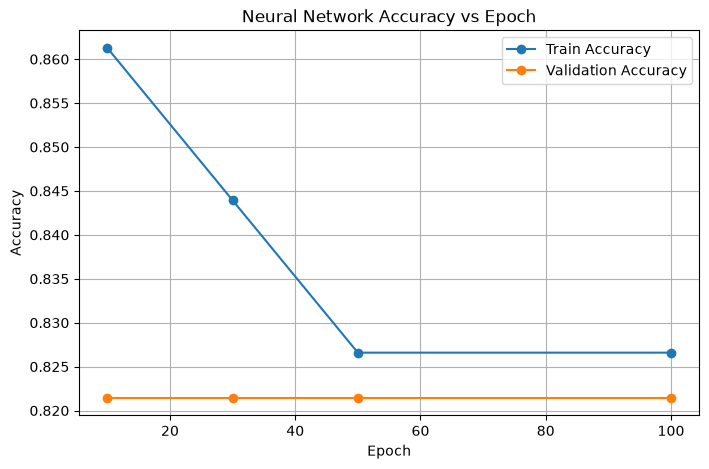

In [184]:
plt.figure(figsize=(8, 5))
plt.plot(epoch_df["Epoch"], epoch_df["Train Accuracy"], marker="o", label="Train Accuracy")
plt.plot(epoch_df["Epoch"], epoch_df["Validation Accuracy"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Neural Network Accuracy vs Epoch")
plt.grid(True)
plt.legend()
plt.show()

## 8. ให้ Neural Network ทำนายความเหมาะสมของอาหารทั้งหมด

ขั้นตอนนี้คือส่วนสำคัญที่ทำให้ระบบจัดเมนูมี **NN อยู่ในกระบวนการจริง**

NN จะรับข้อมูลโภชนาการ → ทำนาย `Suitable / Not Suitable` → ให้ความน่าจะเป็น (`Suitability Score`)

In [185]:
X_all = df[feature_cols].fillna(X_train.median(numeric_only=True))
X_all_scaled = scaler.transform(X_all)

df["NN_Prediction"] = best_model.predict(X_all_scaled)

proba = best_model.predict_proba(X_all_scaled)
class_index = list(best_model.classes_).index("Suitable")
df["Suitability_Score"] = proba[:, class_index]

display(
    df[[energy_col, "NN_Prediction", "Suitability_Score"]]
    .sort_values("Suitability_Score", ascending=False)
    .head(20)
)

,"Energy, by calculation (kcal)",NN_Prediction,Suitability_Score
72,505.0,Suitable,0.615116
258,553.0,Suitable,0.604163
268,495.0,Suitable,0.601930
257,508.0,Suitable,0.601134
155,407.0,Suitable,0.597887
272,526.0,Suitable,0.596929
214,462.0,Suitable,0.595841
280,530.0,Suitable,0.594899
282,460.0,Suitable,0.593351
297,521.0,Suitable,0.591467


## 9. คำนวณพลังงานที่ผู้ใช้ต้องการต่อวัน

ใช้ Mifflin-St Jeor เป็นตัวอย่างในการประมาณ BMR และ TDEE

> ค่านี้เป็นการประมาณเพื่อการเรียนรู้ ไม่ใช่คำแนะนำทางการแพทย์

In [186]:
age = 21
sex = "female"
weight_kg = 60
height_cm = 165
activity_level = "moderate"

activity_factor = {
    "sedentary": 1.20,
    "light": 1.375,
    "moderate": 1.55,
    "very_high": 1.725
}

if sex.lower() == "male":
    bmr = 10 * weight_kg + 6.25 * height_cm - 5 * age + 5
else:
    bmr = 10 * weight_kg + 6.25 * height_cm - 5 * age - 161

tdee = bmr * activity_factor[activity_level]
daily_target = round(tdee)

print(f"BMR ≈ {bmr:.0f} kcal/day")
print(f"TDEE ≈ {tdee:.0f} kcal/day")
print(f"Daily target = {daily_target} kcal/day")

BMR ≈ 1365 kcal/day
TDEE ≈ 2116 kcal/day
Daily target = 2116 kcal/day


## 10. แบ่งเป้าหมายเป็น 3 มื้อ

- อาหารเช้า 25%
- อาหารกลางวัน 40%
- อาหารเย็น 35%

จากนั้นใช้ NN Score ช่วยเลือกอาหาร และใช้เงื่อนไข kcal ควบคุมผลรวม

In [187]:
meal_targets = {
    "Breakfast": daily_target * 0.25,
    "Lunch": daily_target * 0.40,
    "Dinner": daily_target * 0.35
}

meal_targets

{'Breakfast': 529.0, 'Lunch': 846.4000000000001, 'Dinner': 740.5999999999999}

In [188]:
# ใช้เฉพาะอาหารที่ NN ทำนายว่า Suitable
candidates = df[df["NN_Prediction"] == "Suitable"].copy()
candidates["Energy (kcal)"] = candidates[energy_col]

# ถ้า Suitable มีน้อย ให้ใช้ทุกอาหารที่ NN ให้คะแนนสูงสุด
if len(candidates) < 15:
    candidates = df.sort_values("Suitability_Score", ascending=False).head(30).copy()

def choose_meal(candidates, target_kcal, used_indices):
    pool = candidates.copy()

    pool["kcal_error"] = abs(
        pool[energy_col] - target_kcal
    )

    pool = pool.sort_values(
        ["kcal_error", "Suitability_Score"],
        ascending=[True, False]
    ).head(25)

    # สุ่มใหม่ทุกครั้งที่ Run
    sample = pool.sample(
        n=min(10, len(pool))
    )

    sample = sample[
        ~sample.index.isin(used_indices)
    ]

    if len(sample) == 0:
        sample = pool

    sample = sample.copy()

    sample["score"] = (
        abs(sample[energy_col] - target_kcal)
        - 150 * sample["Suitability_Score"]
    )

    # เลือกแบบสุ่มจาก 5 ตัวที่คะแนนดีที่สุด
    top = sample.sort_values("score").head(5)

    return top.sample(1).iloc[0]

used = set()
plan = []

for meal, target in meal_targets.items():
    selected = choose_meal(
        candidates,
        target,
        used
    )

    used.add(selected.name)

    plan.append({
        "Meal": meal,
        "Food": selected.get("thai_name", selected.get("english_name", f"Food #{selected.name}")),
        "Energy (kcal)": selected[energy_col],
        "NN Suitability": selected["NN_Prediction"],
        "NN Score": selected["Suitability_Score"],
        "Meal Target (kcal)": target
    })

plan_df = pd.DataFrame(plan)
display(plan_df)

,Meal,Food,Energy (kcal),NN Suitability,NN Score,Meal Target (kcal)
0,Breakfast,"คุกกี้, บัตเตอร์ & ชีส, รสกาแฟ,วานิลลา",515.0,Suitable,0.584057,529.0
1,Lunch,"นัท, คอกเทล, อบเกลือ",632.0,Suitable,0.511083,846.4
2,Dinner,"อัลมอนด์, อบเกลือ",627.0,Suitable,0.515245,740.6


In [189]:
total_kcal = plan_df["Energy (kcal)"].sum()
remaining = daily_target - total_kcal

print(f"Total daily calories: {total_kcal:.1f} kcal")
print(f"Daily target: {daily_target:.1f} kcal")
print(f"Remaining: {remaining:.1f} kcal")

if total_kcal <= daily_target:
    print("ผลการตรวจสอบ: ไม่เกินเป้าหมายพลังงาน")
else:
    print("ผลการตรวจสอบ: เกินเป้าหมายพลังงาน")

Total daily calories: 1774.0 kcal
Daily target: 2116.0 kcal
Remaining: 342.0 kcal
ผลการตรวจสอบ: ไม่เกินเป้าหมายพลังงาน


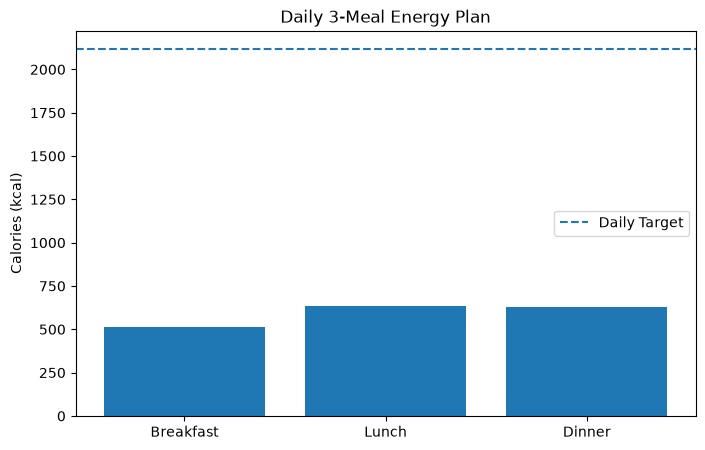

In [190]:
plt.figure(figsize=(8, 5))
plt.bar(plan_df["Meal"], plan_df["Energy (kcal)"])
plt.axhline(daily_target, linestyle="--", label="Daily Target")
plt.ylabel("Calories (kcal)")
plt.title("Daily 3-Meal Energy Plan")
plt.legend()
plt.show()

## 11. สรุปหลักการ Neural Network ของงานนี้

### Input
ข้อมูลโภชนาการของอาหาร เช่น Protein, Fat, Carbohydrate, Sodium และสารอาหารอื่น ๆ

### Hidden Layer
MLP ใช้ Hidden Layer เช่น `(32, 16)` เพื่อเรียนรู้ความสัมพันธ์ที่ไม่เป็นเส้นตรงระหว่างคุณค่าทางโภชนาการกับความเหมาะสมของอาหาร

### Output
NN ทำนาย:
- `Suitable`
- `Not Suitable`

พร้อม `Suitability Score`

### การจัดเมนู
ผลจาก NN ถูกนำไปใช้เป็นหนึ่งในเงื่อนไขเลือกอาหาร แล้วจึงจัดเป็น:
- Breakfast
- Lunch
- Dinner

พร้อมตรวจสอบว่า kcal รวมต่อวันไม่เกินเป้าหมาย

### สรุป
ดังนั้นระบบนี้มีโครงสร้างเป็น:

**Nutrition Data → Neural Network → Food Suitability → 3-Meal Planner → Calorie Check**

จุดสำคัญคือ **NN ทำหน้าที่เรียนรู้และทำนายจริง** ส่วนการจัด 3 มื้อและการควบคุมพลังงานเป็นขั้นตอนหลังจาก NN